# Rolex Watch Price Analysis - Part 2: Database Storage
## PostgreSQL Database Setup and SQL Queries

## Libraries and settings

In [8]:
import os
import pandas as pd
import numpy as np
import psycopg2
from sqlalchemy import create_engine, text
from sqlalchemy.exc import SQLAlchemyError
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)

print(os.getcwd())

/Users/adisaljusi/repos/data_analytics/final


## 1. Database Setup

### Starting the PostgreSQL Database

Before running this notebook, start the PostgreSQL database using Docker Compose:

```bash
docker-compose up -d
```

This will start:
- **PostgreSQL** database on port 5432
- **pgAdmin** web interface on port 5050 (optional)

To stop the database:
```bash
docker-compose down
```

### Database Connection Details:
- **Host**: localhost
- **Port**: 5432
- **Database**: rolex_db
- **User**: rolex_user
- **Password**: rolex_password

## 2. Load Cleaned Data

In [9]:
df = pd.read_csv('rolex_data_cleaned.csv', encoding='utf-8')

print(f"Loaded dataset shape: {df.shape}")
print(f"\nColumn names:")
for i, col in enumerate(df.columns, 1):
    print(f"{i:2d}. {col}")

Loaded dataset shape: (572, 19)

Column names:
 1. web_scraper_order
 2. brand_raw
 3. model_raw
 4. reference_number_raw
 5. movement_type
 6. condition_category
 7. seller_type
 8. case_material_clean
 9. bracelet_material_clean
10. material_category
11. country
12. city
13. price
14. year
15. age
16. has_box
17. has_papers
18. has_complete_set
19. is_professional


In [10]:
df.head()

,web_scraper_order,brand_raw,model_raw,reference_number_raw,movement_type,condition_category,seller_type,case_material_clean,bracelet_material_clean,material_category,country,city,price,year,age,has_box,has_papers,has_complete_set,is_professional
0,1766756167-1,Rolex,Submariner Date,126613lb,Automatic,Incomplete,Professional dealer,Gold/Steel,Gold/Steel,Gold/Steel,United States of America,NEW YORK,14532.0,2020.0,4.0,1,1,1,1
1,1766756169-2,Rolex,GMT-Master II,116713,Automatic,Very Good,Partner Certified Included,Gold/Steel,Gold/Steel,Gold/Steel,United States of America,California,10895.0,NaN,NaN,1,1,1,0
2,1766756171-3,Rolex,GMT-Master II,126711CHNR,Automatic,New,Professional dealer,Gold/Steel,Gold/Steel,Gold/Steel,United States of America,Michigan,18314.0,NaN,NaN,1,1,1,1
3,1766756173-4,Rolex,Yacht-Master II,116680,Automatic,New,Professional dealer,Steel,Steel,Steel,United States of America,Florida,15218.0,2021.0,3.0,1,1,1,1
4,1766756175-5,Rolex,Datejust 41,126334,Automatic,New,Professional dealer,Steel,Steel,Steel,United States of America,California,11299.0,NaN,NaN,1,1,1,1


## 3. Connect to PostgreSQL Database

In [11]:
db_config = {
    'host': 'localhost',
    'port': 5432,
    'database': 'rolex_db',
    'user': 'rolex_user',
    'password': 'rolex_password'
}

connection_string = f"postgresql://{db_config['user']}:{db_config['password']}@{db_config['host']}:{db_config['port']}/{db_config['database']}"

try:
    engine = create_engine(connection_string)
    with engine.connect() as conn:
        result = conn.execute(text("SELECT version();"))
        version = result.fetchone()[0]
        print("✓ Successfully connected to PostgreSQL!")
        print(f"\nDatabase version:")
        print(version)
except Exception as e:
    print(f"✗ Error connecting to database: {e}")
    print("\nMake sure PostgreSQL is running:")
    print("  docker-compose up -d")

✓ Successfully connected to PostgreSQL!

Database version:
PostgreSQL 15.15 on aarch64-unknown-linux-musl, compiled by gcc (Alpine 15.2.0) 15.2.0, 64-bit


## 4. Create Database Tables

### Drop existing table if it exists

In [12]:
with engine.connect() as conn:
    conn.execute(text("DROP TABLE IF EXISTS watches CASCADE;"))
    conn.commit()
    print("✓ Dropped existing 'watches' table (if it existed)")

✓ Dropped existing 'watches' table (if it existed)


### Create watches table

In [13]:
create_table_sql = """
CREATE TABLE watches (
    id SERIAL PRIMARY KEY,
    web_scraper_order VARCHAR(50),
    brand VARCHAR(100),
    model VARCHAR(200),
    reference_number VARCHAR(100),
    movement_type VARCHAR(50),
    condition_category VARCHAR(50),
    seller_type VARCHAR(100),
    case_material VARCHAR(100),
    bracelet_material VARCHAR(100),
    material_category VARCHAR(50),
    country VARCHAR(100),
    city VARCHAR(100),
    price DECIMAL(12, 2),
    year INTEGER,
    age INTEGER,
    has_box INTEGER,
    has_papers INTEGER,
    has_complete_set INTEGER,
    is_professional INTEGER,
    created_at TIMESTAMP DEFAULT CURRENT_TIMESTAMP
);
"""

with engine.connect() as conn:
    conn.execute(text(create_table_sql))
    conn.commit()
    print("✓ Created 'watches' table successfully")

✓ Created 'watches' table successfully


### Create indexes for better query performance

In [14]:
indexes_sql = [
    "CREATE INDEX idx_price ON watches(price);",
    "CREATE INDEX idx_country ON watches(country);",
    "CREATE INDEX idx_condition ON watches(condition_category);",
    "CREATE INDEX idx_material ON watches(material_category);",
    "CREATE INDEX idx_year ON watches(year);"
]

with engine.connect() as conn:
    for idx_sql in indexes_sql:
        conn.execute(text(idx_sql))
    conn.commit()
    print(f"✓ Created {len(indexes_sql)} indexes for performance optimization")

✓ Created 5 indexes for performance optimization


## 5. Load Data into PostgreSQL

In [15]:
df_to_db = df.rename(columns={
    'brand_raw': 'brand',
    'model_raw': 'model',
    'reference_number_raw': 'reference_number',
    'case_material_clean': 'case_material',
    'bracelet_material_clean': 'bracelet_material'
})

print(f"Loading {len(df_to_db):,} records into PostgreSQL...")

try:
    df_to_db.to_sql(
        name='watches',
        con=engine,
        if_exists='append',
        index=False,
        method='multi',
        chunksize=1000
    )
    print(f"✓ Successfully loaded {len(df_to_db):,} records into database")
except Exception as e:
    print(f"✗ Error loading data: {e}")

Loading 572 records into PostgreSQL...
✓ Successfully loaded 572 records into database


### Verify data was loaded

In [16]:
with engine.connect() as conn:
    result = conn.execute(text("SELECT COUNT(*) FROM watches;"))
    count = result.fetchone()[0]
    print(f"Total records in database: {count:,}")

Total records in database: 572


## 6. SQL Queries and Analysis

### 6.1 Basic Statistics

In [17]:
query = """
SELECT 
    COUNT(*) as total_watches,
    ROUND(AVG(price)::numeric, 2) as avg_price,
    ROUND(MIN(price)::numeric, 2) as min_price,
    ROUND(MAX(price)::numeric, 2) as max_price,
    ROUND(STDDEV(price)::numeric, 2) as std_price,
    PERCENTILE_CONT(0.5) WITHIN GROUP (ORDER BY price) as median_price
FROM watches;
"""

df_stats = pd.read_sql_query(query, engine)
print("Overall Price Statistics:")
df_stats

Overall Price Statistics:


,total_watches,avg_price,min_price,max_price,std_price,median_price
0,572,19141.81,3068.0,101722.0,15844.54,14124.0


### 6.2 Average Price by Condition

In [18]:
query = """
SELECT 
    condition_category,
    COUNT(*) as count,
    ROUND(AVG(price)::numeric, 2) as avg_price,
    ROUND(MIN(price)::numeric, 2) as min_price,
    ROUND(MAX(price)::numeric, 2) as max_price
FROM watches
GROUP BY condition_category
ORDER BY avg_price DESC;
"""

df_condition = pd.read_sql_query(query, engine)
print("Price Statistics by Condition:")
df_condition

Price Statistics by Condition:


,condition_category,count,avg_price,min_price,max_price
0,New,245,21893.67,6377.0,101722.0
1,Very Good,290,17898.98,3068.0,91835.0
2,Incomplete,1,14532.00,14532.0,14532.0
3,Good,36,10553.58,3916.0,34715.0


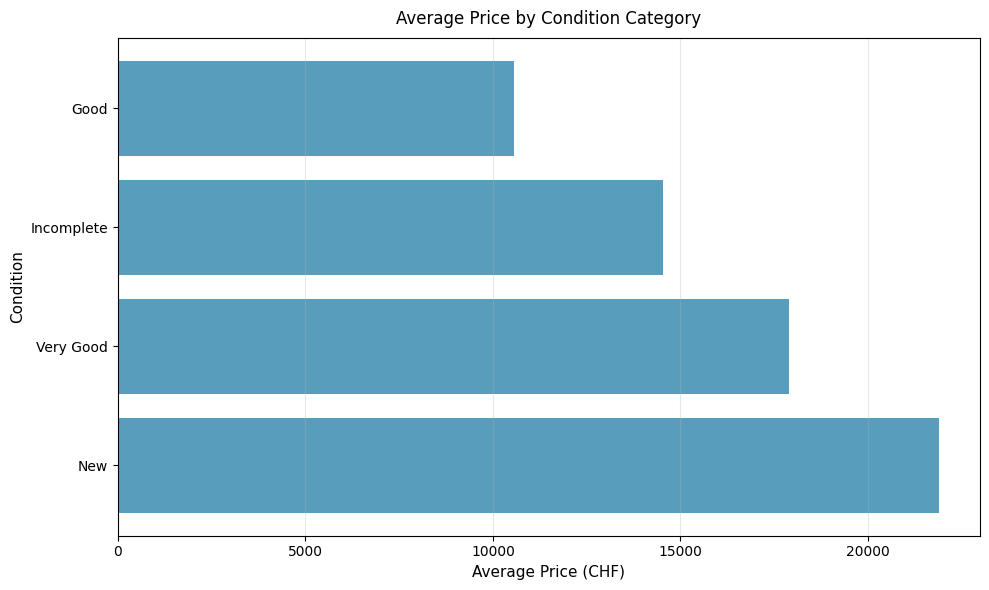

In [19]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(df_condition['condition_category'], df_condition['avg_price'], 
        color='#2E86AB', alpha=0.8)
ax.set_xlabel('Average Price (CHF)', fontsize=11)
ax.set_ylabel('Condition', fontsize=11)
ax.set_title('Average Price by Condition Category', fontsize=12, pad=10)
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

### 6.3 Average Price by Material Category

In [20]:
query = """
SELECT 
    material_category,
    COUNT(*) as count,
    ROUND(AVG(price)::numeric, 2) as avg_price,
    ROUND(MIN(price)::numeric, 2) as min_price,
    ROUND(MAX(price)::numeric, 2) as max_price
FROM watches
WHERE material_category != 'Unknown'
GROUP BY material_category
HAVING COUNT(*) >= 10
ORDER BY avg_price DESC;
"""

df_material = pd.read_sql_query(query, engine)
print("Price Statistics by Material Category:")
df_material

Price Statistics by Material Category:


,material_category,count,avg_price,min_price,max_price
0,Platinum,14,73767.14,58027.0,101722.0
1,Rose Gold,30,42092.77,12716.0,91633.0
2,White Gold,25,38735.68,4436.0,98898.0
3,Yellow Gold,43,35433.30,5247.0,79519.0
4,Gold/Steel,114,14296.83,3916.0,24216.0
5,Steel,339,12936.57,3068.0,29265.0


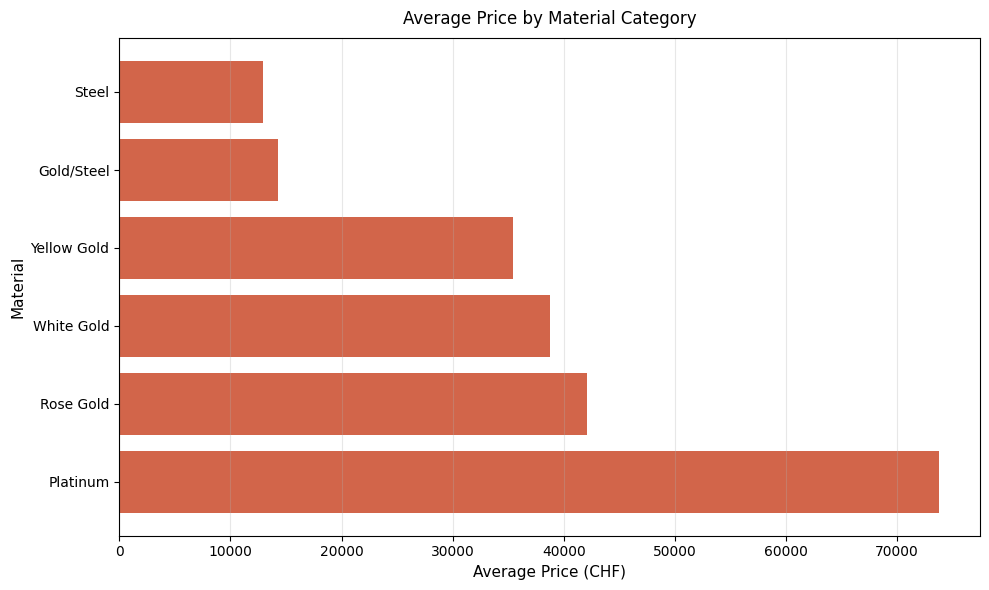

In [21]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(df_material['material_category'], df_material['avg_price'], 
        color='#C73E1D', alpha=0.8)
ax.set_xlabel('Average Price (CHF)', fontsize=11)
ax.set_ylabel('Material', fontsize=11)
ax.set_title('Average Price by Material Category', fontsize=12, pad=10)
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

### 6.4 Top 10 Countries by Number of Listings

In [22]:
query = """
SELECT 
    country,
    COUNT(*) as num_listings,
    ROUND(AVG(price)::numeric, 2) as avg_price,
    ROUND((COUNT(*) * 100.0 / (SELECT COUNT(*) FROM watches))::numeric, 2) as percentage
FROM watches
WHERE country != 'Unknown'
GROUP BY country
ORDER BY num_listings DESC
LIMIT 10;
"""

df_countries = pd.read_sql_query(query, engine)
print("Top 10 Countries by Number of Listings:")
df_countries

Top 10 Countries by Number of Listings:


,country,num_listings,avg_price,percentage
0,United States of America,572,19141.81,100.0


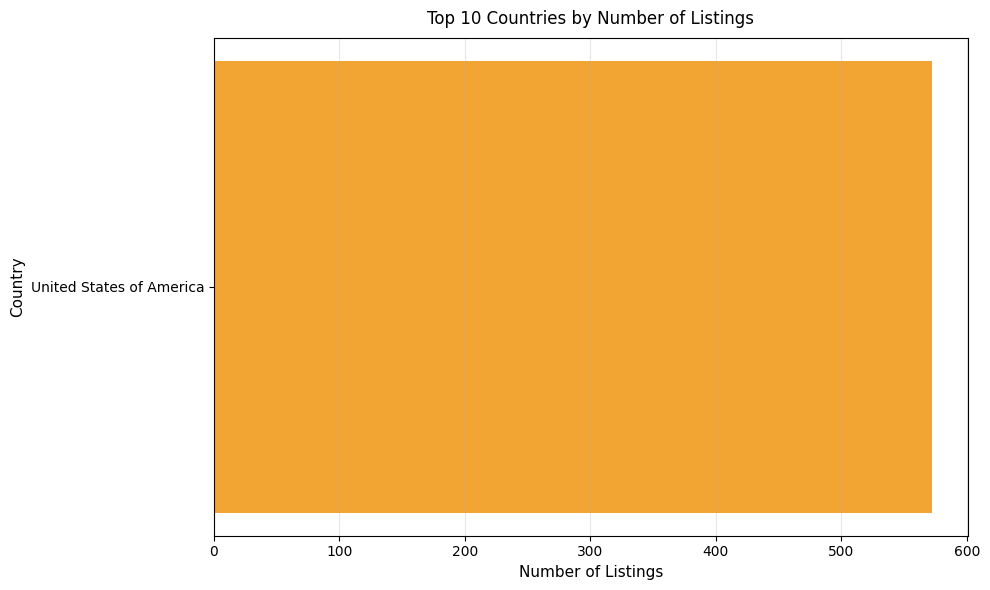

In [23]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(df_countries['country'], df_countries['num_listings'], 
        color='#F18F01', alpha=0.8)
ax.set_xlabel('Number of Listings', fontsize=11)
ax.set_ylabel('Country', fontsize=11)
ax.set_title('Top 10 Countries by Number of Listings', fontsize=12, pad=10)
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

### 6.5 Impact of Documentation on Price

In [24]:
query = """
SELECT 
    CASE 
        WHEN has_complete_set = 1 THEN 'Complete Set (Box + Papers)'
        WHEN has_box = 1 AND has_papers = 0 THEN 'Box Only'
        WHEN has_box = 0 AND has_papers = 1 THEN 'Papers Only'
        ELSE 'No Documentation'
    END as documentation,
    COUNT(*) as count,
    ROUND(AVG(price)::numeric, 2) as avg_price,
    ROUND(MIN(price)::numeric, 2) as min_price,
    ROUND(MAX(price)::numeric, 2) as max_price
FROM watches
GROUP BY 
    CASE 
        WHEN has_complete_set = 1 THEN 'Complete Set (Box + Papers)'
        WHEN has_box = 1 AND has_papers = 0 THEN 'Box Only'
        WHEN has_box = 0 AND has_papers = 1 THEN 'Papers Only'
        ELSE 'No Documentation'
    END
ORDER BY avg_price DESC;
"""

df_docs = pd.read_sql_query(query, engine)
print("Price Statistics by Documentation:")
df_docs

Price Statistics by Documentation:


,documentation,count,avg_price,min_price,max_price
0,Complete Set (Box + Papers),572,19141.81,3068.0,101722.0


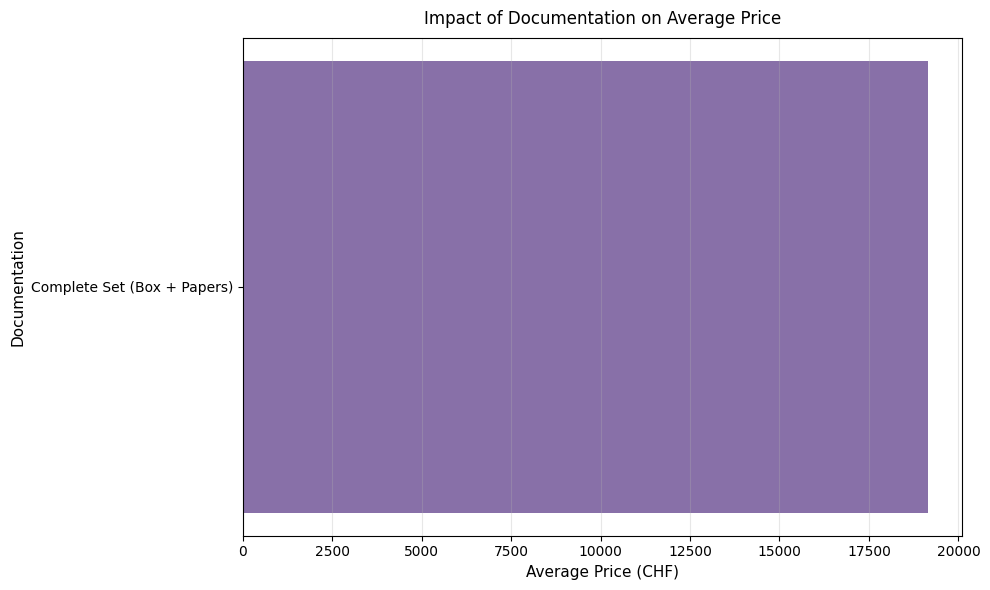

In [25]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(df_docs['documentation'], df_docs['avg_price'], 
        color='#6A4C93', alpha=0.8)
ax.set_xlabel('Average Price (CHF)', fontsize=11)
ax.set_ylabel('Documentation', fontsize=11)
ax.set_title('Impact of Documentation on Average Price', fontsize=12, pad=10)
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

### 6.6 Professional Dealers vs Private Sellers

In [26]:
query = """
SELECT 
    seller_type,
    COUNT(*) as count,
    ROUND(AVG(price)::numeric, 2) as avg_price,
    ROUND(STDDEV(price)::numeric, 2) as std_price,
    PERCENTILE_CONT(0.5) WITHIN GROUP (ORDER BY price) as median_price
FROM watches
GROUP BY seller_type
ORDER BY avg_price DESC;
"""

df_sellers = pd.read_sql_query(query, engine)
print("Price Statistics by Seller Type:")
df_sellers

Price Statistics by Seller Type:


,seller_type,count,avg_price,std_price,median_price
0,Private Seller,15,24064.93,20237.75,14415.0
1,Professional dealer,452,19753.77,15822.95,14492.0
2,Partner Certified Included,105,15804.15,14870.54,10495.0


### 6.7 Price Distribution by Age Groups

In [27]:
query = """
SELECT 
    CASE 
        WHEN age < 5 THEN '0-4 years (Modern)'
        WHEN age >= 5 AND age < 15 THEN '5-14 years (Recent)'
        WHEN age >= 15 AND age < 25 THEN '15-24 years (Pre-owned)'
        WHEN age >= 25 AND age < 40 THEN '25-39 years (Vintage)'
        WHEN age >= 40 THEN '40+ years (Antique)'
        ELSE 'Unknown'
    END as age_group,
    COUNT(*) as count,
    ROUND(AVG(price)::numeric, 2) as avg_price,
    ROUND(MIN(price)::numeric, 2) as min_price,
    ROUND(MAX(price)::numeric, 2) as max_price
FROM watches
WHERE age IS NOT NULL
GROUP BY 
    CASE 
        WHEN age < 5 THEN '0-4 years (Modern)'
        WHEN age >= 5 AND age < 15 THEN '5-14 years (Recent)'
        WHEN age >= 15 AND age < 25 THEN '15-24 years (Pre-owned)'
        WHEN age >= 25 AND age < 40 THEN '25-39 years (Vintage)'
        WHEN age >= 40 THEN '40+ years (Antique)'
        ELSE 'Unknown'
    END
ORDER BY avg_price DESC;
"""

df_age_groups = pd.read_sql_query(query, engine)
print("Price Statistics by Age Group:")
df_age_groups

Price Statistics by Age Group:


,age_group,count,avg_price,min_price,max_price
0,0-4 years (Modern),224,21032.12,6697.0,101722.0
1,5-14 years (Recent),91,17931.69,4679.0,91633.0
2,15-24 years (Pre-owned),30,13135.83,5042.0,35422.0
3,25-39 years (Vintage),31,9761.32,3940.0,32193.0
4,40+ years (Antique),12,8376.00,3068.0,18528.0


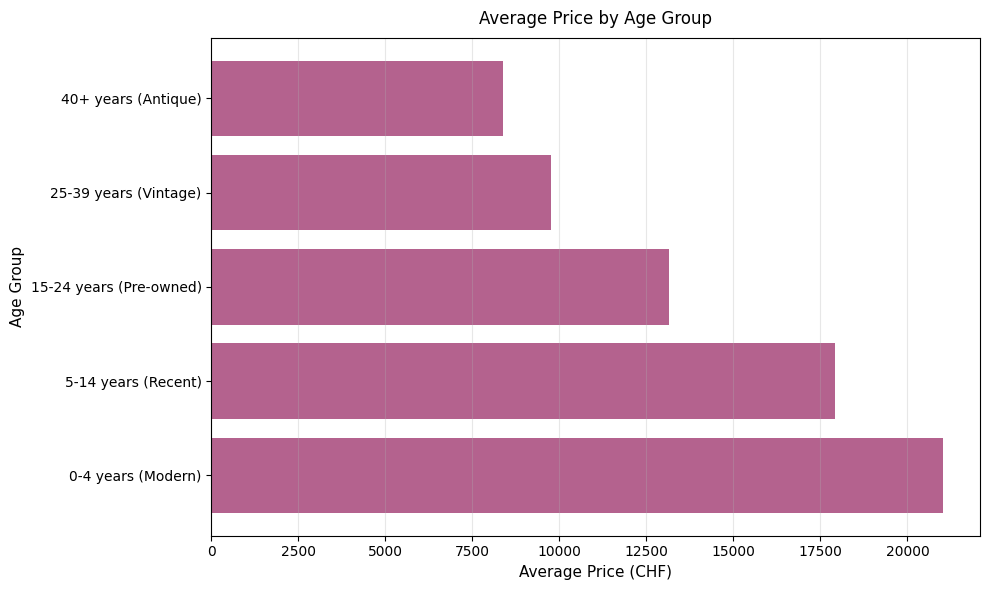

In [28]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(df_age_groups['age_group'], df_age_groups['avg_price'], 
        color='#A23B72', alpha=0.8)
ax.set_xlabel('Average Price (CHF)', fontsize=11)
ax.set_ylabel('Age Group', fontsize=11)
ax.set_title('Average Price by Age Group', fontsize=12, pad=10)
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

### 6.8 Most Expensive Watches

In [29]:
query = """
SELECT 
    model,
    reference_number,
    material_category,
    condition_category,
    year,
    country,
    price,
    seller_type
FROM watches
ORDER BY price DESC
LIMIT 10;
"""

df_expensive = pd.read_sql_query(query, engine)
print("Top 10 Most Expensive Watches:")
df_expensive

Top 10 Most Expensive Watches:


,model,reference_number,material_category,condition_category,year,country,price,seller_type
0,Daytona,126506,Platinum,New,2024.0,United States of America,101722.0,Professional dealer
1,Daytona,126519LN,White Gold,New,NaN,United States of America,98898.0,Professional dealer
2,Daytona,126506,Platinum,New,2023.0,United States of America,92197.0,Professional dealer
3,Daytona,116506\n \n ...,Platinum,Very Good,2022.0,United States of America,91835.0,Partner Certified Included
4,Yacht-Master 40,116695 SATS,Rose Gold,Very Good,2017.0,United States of America,91633.0,Professional dealer
5,Daytona,126518ln,Yellow Gold,New,NaN,United States of America,79519.0,Professional dealer
6,GMT-Master II,126715CHNR,Rose Gold,New,NaN,United States of America,77803.0,Professional dealer
7,Daytona,126518ln\n \n ...,Yellow Gold,New,NaN,United States of America,77504.0,Professional dealer
8,Daytona,116506\n \n ...,Platinum,Very Good,2016.0,United States of America,75486.0,Professional dealer
9,Daytona,116506\n \n ...,Platinum,Very Good,2019.0,United States of America,74174.0,Professional dealer


### 6.9 Most Common Models

In [30]:
query = """
SELECT 
    model,
    COUNT(*) as count,
    ROUND(AVG(price)::numeric, 2) as avg_price,
    ROUND(MIN(price)::numeric, 2) as min_price,
    ROUND(MAX(price)::numeric, 2) as max_price
FROM watches
WHERE model IS NOT NULL AND model != 'None'
GROUP BY model
ORDER BY count DESC
LIMIT 15;
"""

df_models = pd.read_sql_query(query, engine)
print("Top 15 Most Common Models:")
df_models

Top 15 Most Common Models:


,model,count,avg_price,min_price,max_price
0,GMT-Master II,78,18547.29,8961.0,77803.0
1,Submariner Date,61,15435.62,7262.0,39152.0
2,Daytona,61,40394.28,12513.0,101722.0
3,Datejust 41,59,12664.92,7992.0,19372.0
4,Datejust 36,55,9389.56,3916.0,17354.0
5,Lady-Datejust,33,16755.36,3940.0,44400.0
6,Sky-Dweller,25,23052.16,14363.0,62549.0
7,Day-Date 40,25,52605.68,34453.0,69421.0
8,Yacht-Master 40,20,17643.60,6858.0,91633.0
9,Datejust 31,19,14456.68,6051.0,20987.0


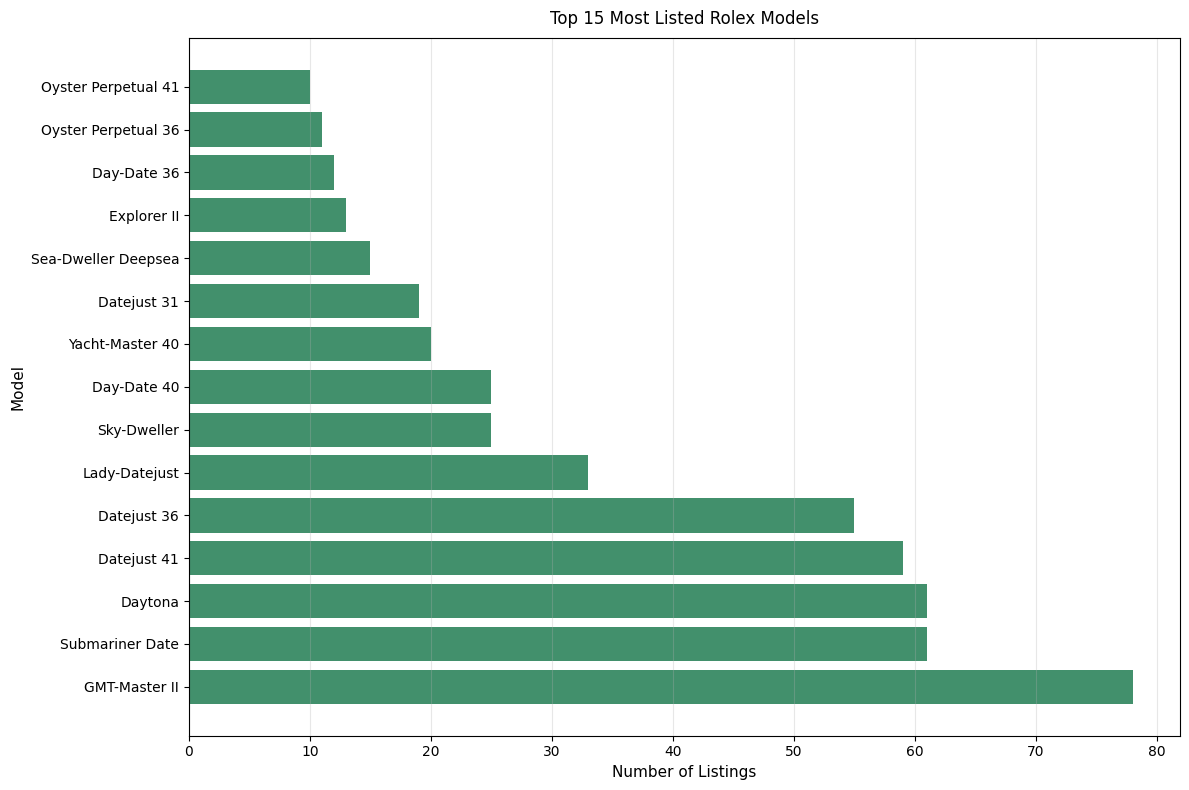

In [31]:
fig, ax = plt.subplots(figsize=(12, 8))
ax.barh(df_models['model'], df_models['count'], 
        color='#137547', alpha=0.8)
ax.set_xlabel('Number of Listings', fontsize=11)
ax.set_ylabel('Model', fontsize=11)
ax.set_title('Top 15 Most Listed Rolex Models', fontsize=12, pad=10)
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

### 6.10 Complex Query: Best Value Watches

In [32]:
query = """
WITH avg_prices AS (
    SELECT 
        material_category,
        AVG(price) as avg_mat_price
    FROM watches
    WHERE material_category != 'Unknown'
    GROUP BY material_category
)
SELECT 
    w.model,
    w.reference_number,
    w.material_category,
    w.condition_category,
    w.year,
    w.country,
    w.price,
    ROUND(ap.avg_mat_price::numeric, 2) as avg_category_price,
    ROUND(((w.price - ap.avg_mat_price) / ap.avg_mat_price * 100)::numeric, 2) as price_deviation_pct
FROM watches w
JOIN avg_prices ap ON w.material_category = ap.material_category
WHERE w.condition_category IN ('New', 'Very Good', 'Good')
    AND w.has_complete_set = 1
    AND w.material_category IN ('Steel', 'Gold/Steel')
ORDER BY price_deviation_pct ASC
LIMIT 20;
"""

df_value = pd.read_sql_query(query, engine)
print("Top 20 Best Value Watches (Below Average Price for Material):")
df_value

Top 20 Best Value Watches (Below Average Price for Material):


,model,reference_number,material_category,condition_category,year,country,price,avg_category_price,price_deviation_pct
0,Oysterdate Precision,6694,Steel,Very Good,1962.0,United States of America,3068.0,12936.57,-76.28
1,Datejust 36,16013\n \n ...,Gold/Steel,Good,1978.0,United States of America,3916.0,14296.83,-72.61
2,Lady-Datejust,69173,Gold/Steel,Very Good,1992.0,United States of America,3940.0,14296.83,-72.44
3,Datejust 36,16013,Gold/Steel,Good,1978.0,United States of America,4036.0,14296.83,-71.77
4,Lady-Datejust,69173,Gold/Steel,Very Good,1991.0,United States of America,4359.0,14296.83,-69.51
5,Datejust 36,16030,Steel,Good,NaN,United States of America,4033.0,12936.57,-68.82
6,Datejust 36,16014,Steel,Very Good,1978.0,United States of America,4197.0,12936.57,-67.56
7,Lady-Datejust,69173,Gold/Steel,Very Good,1996.0,United States of America,4763.0,14296.83,-66.68
8,Datejust 36,16013,Gold/Steel,Very Good,NaN,United States of America,4844.0,14296.83,-66.12
9,Datejust 36,16013,Gold/Steel,Very Good,1981.0,United States of America,5006.0,14296.83,-64.99


## 7. Save Query Results for Further Analysis

In [33]:
query = "SELECT * FROM watches;"
df_from_db = pd.read_sql_query(query, engine)

print(f"Retrieved {len(df_from_db):,} records from database")
print(f"\nFirst few records:")
df_from_db.head()

Retrieved 572 records from database

First few records:


,id,web_scraper_order,brand,model,reference_number,movement_type,condition_category,seller_type,case_material,bracelet_material,material_category,country,city,price,year,age,has_box,has_papers,has_complete_set,is_professional,created_at
0,1,1766756167-1,Rolex,Submariner Date,126613lb,Automatic,Incomplete,Professional dealer,Gold/Steel,Gold/Steel,Gold/Steel,United States of America,NEW YORK,14532.0,2020.0,4.0,1,1,1,1,2025-12-26 18:56:41.512142
1,2,1766756169-2,Rolex,GMT-Master II,116713,Automatic,Very Good,Partner Certified Included,Gold/Steel,Gold/Steel,Gold/Steel,United States of America,California,10895.0,NaN,NaN,1,1,1,0,2025-12-26 18:56:41.512142
2,3,1766756171-3,Rolex,GMT-Master II,126711CHNR,Automatic,New,Professional dealer,Gold/Steel,Gold/Steel,Gold/Steel,United States of America,Michigan,18314.0,NaN,NaN,1,1,1,1,2025-12-26 18:56:41.512142
3,4,1766756173-4,Rolex,Yacht-Master II,116680,Automatic,New,Professional dealer,Steel,Steel,Steel,United States of America,Florida,15218.0,2021.0,3.0,1,1,1,1,2025-12-26 18:56:41.512142
4,5,1766756175-5,Rolex,Datejust 41,126334,Automatic,New,Professional dealer,Steel,Steel,Steel,United States of America,California,11299.0,NaN,NaN,1,1,1,1,2025-12-26 18:56:41.512142


## 8. Database Information

In [34]:
query = """
SELECT 
    table_name,
    pg_size_pretty(pg_total_relation_size(quote_ident(table_name)::regclass)) AS size
FROM information_schema.tables
WHERE table_schema = 'public'
ORDER BY pg_total_relation_size(quote_ident(table_name)::regclass) DESC;
"""

df_table_sizes = pd.read_sql_query(query, engine)
print("Database Tables and Sizes:")
df_table_sizes

Database Tables and Sizes:


,table_name,size
0,watches,304 kB


In [37]:
query = """
SELECT 
    indexrelname,
    relname,
    pg_size_pretty(pg_relation_size(indexrelid)) AS size
FROM pg_stat_user_indexes
ORDER BY pg_relation_size(indexrelid) DESC;
"""

df_indexes = pd.read_sql_query(query, engine)
print("Database Indexes:")
df_indexes

Database Indexes:


,indexrelname,relname,size
0,idx_price,watches,40 kB
1,watches_pkey,watches,32 kB
2,idx_country,watches,16 kB
3,idx_condition,watches,16 kB
4,idx_material,watches,16 kB
5,idx_year,watches,16 kB


## Jupyter notebook --footer info-- (please always provide this at the end of each submitted notebook)

In [ ]:
import os
import platform
from platform import python_version
from datetime import datetime

print('-----------------------------------')
print(os.name.upper())
print(platform.system(), '|', platform.release())
print('Datetime:', datetime.now().strftime("%Y-%m-%d %H:%M:%S"))
print('Python Version:', python_version())
print('-----------------------------------')